<a href="https://colab.research.google.com/github/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/blob/main/Mini_Hackathon_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA & CLEANING

In [ ]:
# Participants: 1. Joshua W. Smith 2. Marcus H. Grigsby 3. Obed A. Dolo

import pandas as pd
url = "https://raw.githubusercontent.com/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/refs/heads/main/dirty_cafe_sales.csv"
df = pd.read_csv(url)

# -----Inspect------

print("=== ORIGINAL DATA ===")
print("\n")
print("Shape:", df.shape)
print("\n")
print(df.head())
print("\n")
print(df.info())
print("\n")
print(df.isnull().sum())
print("\n")
print(df.describe())

=== ORIGINAL DATA ===


Shape: (200, 7)


  ﻿Transaction ID    Item  Quantity  Price Per Unit Total Spent  \
0         TXN_001  Coffee         2             2.0         4.0   
1         TXN_002    Cake         4             3.0        12.0   
2         TXN_003  Cookie         4             1.0       ERROR   
3         TXN_004   Salad         2             5.0        10.0   
4         TXN_005  Coffee         2             2.0         4.0   

   Payment Method  Location  
0     Credit Card  Takeaway  
1            Cash  In-store  
2     Credit Card  In-store  
3         UNKNOWN   UNKNOWN  
4  Digital Wallet  In-store  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ﻿Transaction ID  200 non-null    object 
 1   Item             199 non-null    object 
 2   Quantity         200 non-null    int64  
 3   Price Per Unit   200 non-null    f

In [ ]:
import numpy as np

#------Clean-------
# 1. Replace 'ERROR' with NaN
df = df.replace('ERROR',np.nan)

# 2. Convert numeric columns
df['Quantity'] = pd.to_numeric(df['Quantity'],  errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'],  errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'],  errors='coerce')

# 3. Fill missing numeric values with MEDIAN
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())

# 4. Fill missing categorical values with MODE
for col in ['Item', 'Payment Method', 'Location']:
  mode_val = df[col].mode()[0]
  df[col] = df[col].fillna(mode_val)

  # 5. Remove outlier rows (Quantity > 20)
  df_clean = df[df['Quantity']<=20]

  #-----Verify------
  print("=== CLEANED DATA ===")
  print("\n")
  print(f"Rows before: {len(df)}")
  print("\n")
  print(f"Rows after: {len(df_clean)}")
  print(df_clean.describe())

  # Q1 Ans: There where 200 rows original dataset and after cleaning there where 199 left.
  # Q2Ans: The median value that was use to fill the missing Quantity value is 3.645000.
  # Q3 Ans: We remove rows where the 'Quantity' was greater than 20 because these values were considered outliers.
  # By removing quantities greater than 20, we are trying to create a df_clean DataFrame that is more representative of typical cafe sales transactions, which can lead to a more robust and accurate machine learning model.
  # Q4 Ans: By using the median, you're filling missing values with a number that genuinely represents the 'middle' or 'typical' value of the Quantity column, making your imputed data more reliable.



=== CLEANED DATA ===


Rows before: 200


Rows after: 199
         Quantity  Price Per Unit  Total Spent
count  199.000000      199.000000   199.000000
mean     3.211055        2.962312     9.432161
std      1.383773        1.287993     5.944114
min      1.000000        1.000000     1.000000
25%      2.000000        2.000000     4.500000
50%      3.000000        3.000000     8.000000
75%      4.000000        4.000000    12.000000
max      5.000000        5.000000    25.000000
=== CLEANED DATA ===


Rows before: 200


Rows after: 199
         Quantity  Price Per Unit  Total Spent
count  199.000000      199.000000   199.000000
mean     3.211055        2.962312     9.432161
std      1.383773        1.287993     5.944114
min      1.000000        1.000000     1.000000
25%      2.000000        2.000000     4.500000
50%      3.000000        3.000000     8.000000
75%      4.000000        4.000000    12.000000
max      5.000000        5.000000    25.000000
=== CLEANED DATA ===


Rows before: 20

Part 2 : LOGISTIC REGESSION - TRAIN , EVALUATE, SAVE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Corrected typo: matlplotlib -> matplotlib
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score # Added precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler # Added StandardScaler import

# 1. Load dataset (df is already loaded and cleaned in a previous cell, so these lines are removed/commented)
# from google.colab import files # Corrected typo: goole -> google
# uploaded = files.upload() # Corrected call: files. upload -> files.upload()
# df = pd.read_csv('dirty_cafe_sales.csv') # Removed redundant loading

# 2. Prepare features and target
# Original columns 'Age' and 'Salary' do not exist in the dataframe. Using existing numerical columns.
# Creating a binary target 'is_high_spent' from 'Total Spent' for logistic regression example.
# Assuming 'Total Spent' > median of 'Total Spent' is considered 'high spent'
df['is_high_spent'] = (df['Total Spent'] > df['Total Spent'].median()).astype(int)
x = df[['Quantity', 'Price Per Unit', 'Total Spent']] # features - using existing numerical columns
y = df['is_high_spent'] # target - using the newly created binary target

# 3. Train/test split (75/25)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0) # Corrected typo: y_trian -> y_train

# 4. Scaler = features (fit only on training data)
scaler = StandardScaler() # Corrected typo: Standarscalar. -> StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # Corrected typo: fit_transfrom -> fit_transform
x_test_scaled = scaler.transform(x_test)

# 5. Train logistic regression

model = LogisticRegression(random_state=0) # Corrected indentation
model.fit(x_train_scaled, y_train)

# 6. Predict
y_pred = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)[:, 1]

# 7. Evaluation metrics
print("=" * 50)
print("MODEL PERFORMANCE ON TEST DATA")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100: .2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}") # Added Precision metric
print(f"Recall:    {recall_score(y_test, y_pred):.4f}") # Added Recall metric
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}") # Added F1-Score metric
print("\nConfusion Matrix:") # Added Confusion Matrix
print(confusion_matrix(y_test, y_pred))


MODEL PERFORMANCE ON TEST DATA
Accuracy :  94.00%
Precision: 1.0000
Recall:    0.8696
F1-Score:  0.9302

Confusion Matrix:
[[27  0]
 [ 3 20]]


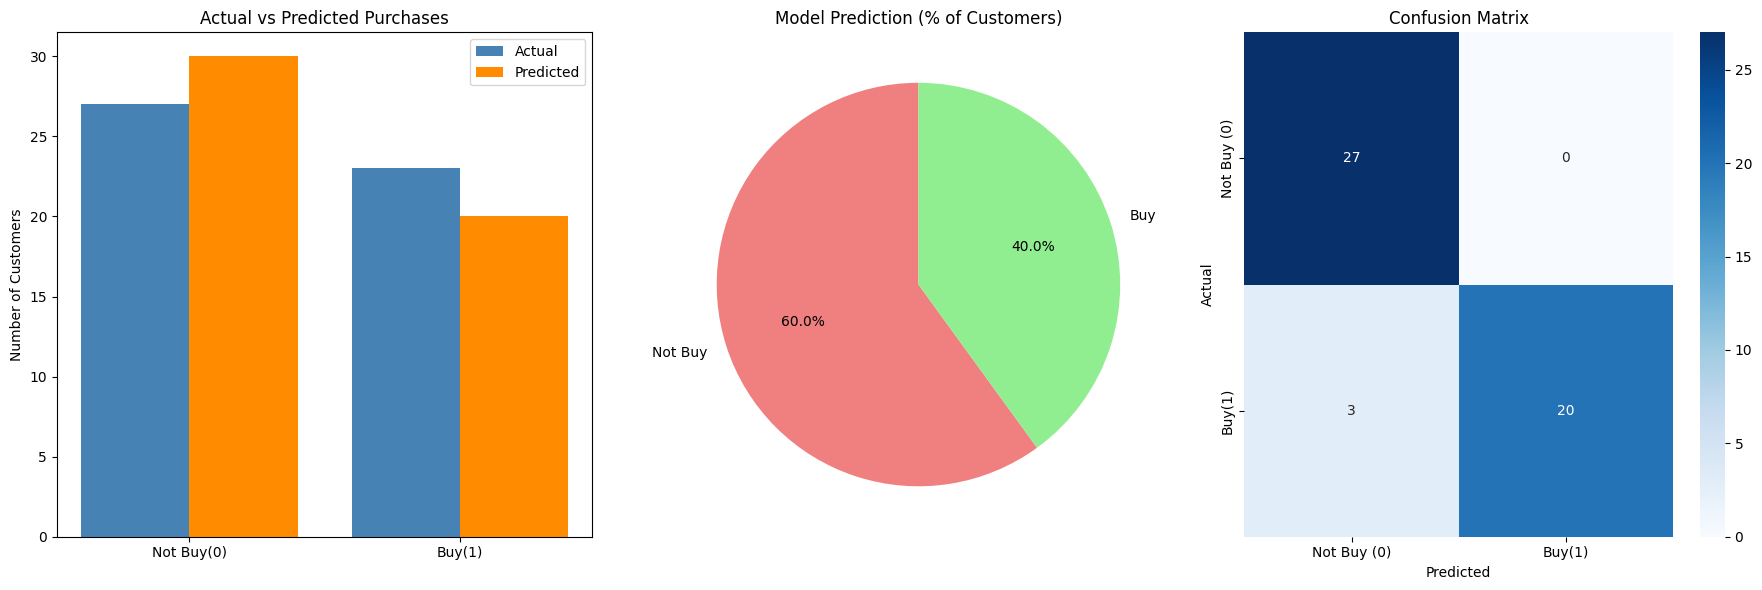


Saved: model.pkl | scaler.pkl


In [ ]:
import seaborn as sns # Import seaborn for heatmap
from sklearn.metrics import confusion_matrix # Import confusion_matrix for the heatmap

# Calculate confusion matrix for plotting
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18,6)) # Adjusted figure size for 3 subplots

# 8. Plot 1 - Actual vs Predicted counts (Bar Chart)
plt.subplot(1,3,1) # Changed to 1,3,1
categories = ['Not Buy(0)', 'Buy(1)']
actual_counts = [sum(y_test ==0), sum(y_test ==1)]
pred_counts = [sum(y_pred ==0), sum(y_pred ==1)]
x = range(len(categories))
plt.bar(x,actual_counts, width=0.4, label='Actual', color='steelblue')
plt.bar([i+0.4 for i in x],pred_counts, width=0.4, label='Predicted', color='darkorange')
plt.xticks([i+0.2 for i in x], categories)
plt.ylabel('Number of Customers')
plt.title('Actual vs Predicted Purchases')
plt.legend()

# 9. Plot 2 - Pie Chart of Predictions
plt.subplot(1,3,2) # Changed to 1,3,2
buy_count = sum(y_pred == 1)
not_buy_count = sum(y_pred == 0)
plt.pie([not_buy_count, buy_count], labels=['Not Buy', 'Buy'], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=90) # Corrected plt.ple to plt.pie
plt.title('Model Prediction (% of Customers)') # Added space to title

# 9. Plot 3 - Confusion Matrix Heatmap
plt.subplot(1,3,3) # Changed to 1,3,3
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues', xticklabels=['Not Buy (0)', 'Buy(1)'],
            yticklabels=['Not Buy (0)', 'Buy(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

# 10. Save the model and Scaler
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nSaved: model.pkl | scaler.pkl")

# Q1 Ans: The Accuracy percentage was 94.00%
# Q2 Ans: The two correct predicted numbers are 27 and 20.
# Q3 Ans: They are not the same telling you that the price was different.
# Q4 Ans:
# Q5 Ans: They are use to save the model and scaler.